1. Install packages

In [16]:
!pip install torch_geometric -q

2. Imports and setup

In [17]:
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.datasets import TUDataset
from torch_geometric.loader import DataLoader
from torch_geometric.transforms import OneHotDegree
from torch_geometric.utils import degree
from torch_geometric.nn import (
    GCNConv,
    GINConv,
    SGConv,
    global_add_pool
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(42)

Device: cuda


3. Load dataset

In [ ]:
DATASET_NAME = "NCI1"   

dataset = TUDataset(
    root=f"/content/{DATASET_NAME}",
    name=DATASET_NAME
)

print(dataset)
print("Number of graphs:", len(dataset))
print("Number of classes:", dataset.num_classes)
print("Original node feature dimension:", dataset.num_node_features)

NCI1(4110)
Number of graphs: 4110
Number of classes: 2
Original node feature dimension: 37


4. Handle missing node features

In [19]:
if dataset.num_node_features == 0:
    max_degree = 0

    for data in dataset:
        deg = degree(data.edge_index[0], num_nodes=data.num_nodes)
        max_degree = max(max_degree, int(deg.max().item()))

    max_degree = min(max_degree, 100)

    dataset = TUDataset(
        root=f"/content/{DATASET_NAME}_degree",
        name=DATASET_NAME,
        transform=OneHotDegree(max_degree)
    )

print("Final node feature dimension:", dataset.num_node_features)

Final node feature dimension: 37


5. Train / Val / Test split

In [20]:
set_seed(42)

dataset = dataset.shuffle()

n = len(dataset)

train_size = int(0.8 * n)
val_size = int(0.1 * n)
test_size = n - train_size - val_size

train_dataset = dataset[:train_size]
val_dataset = dataset[train_size:train_size + val_size]
test_dataset = dataset[train_size + val_size:]

batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 3288
Val: 411
Test: 411


6. Models

6.1 SGC Graph Classifier

In [21]:
class SGCGraphClassifier(nn.Module):
    def __init__(self, in_channels, out_channels, K=2, dropout=0.2):
        super().__init__()

        self.sgc = SGConv(
            in_channels=in_channels,
            out_channels=in_channels,
            K=K,
            cached=False,
            bias=False
        )

        self.classifier = nn.Linear(in_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index, batch):
        x = self.sgc(x, edge_index)

        x = global_add_pool(x, batch)

        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.classifier(x)

        return x

6.2 GCN Graph Classifier

In [22]:
class GCNGraphClassifier(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.2):
        super().__init__()

        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)

        self.bn1 = nn.BatchNorm1d(hidden_channels)
        self.bn2 = nn.BatchNorm1d(hidden_channels)

        self.classifier = nn.Linear(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)

        x = global_add_pool(x, batch)

        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.classifier(x)

        return x

6.3 GIN Graph Classifier

In [23]:
class GINGraphClassifier(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.2):
        super().__init__()

        mlp1 = nn.Sequential(
            nn.Linear(in_channels, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, hidden_channels)
        )

        mlp2 = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, hidden_channels)
        )

        self.conv1 = GINConv(mlp1)
        self.conv2 = GINConv(mlp2)

        self.bn1 = nn.BatchNorm1d(hidden_channels)
        self.bn2 = nn.BatchNorm1d(hidden_channels)

        self.classifier = nn.Linear(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)

        x = global_add_pool(x, batch)

        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.classifier(x)

        return x

7. Train and evaluation functions

In [24]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for data in loader:
        data = data.to(device)

        optimizer.zero_grad()

        out = model(
            data.x.float(),
            data.edge_index,
            data.batch
        )

        loss = criterion(out, data.y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * data.num_graphs

    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()

    correct = 0

    for data in loader:
        data = data.to(device)

        out = model(
            data.x.float(),
            data.edge_index,
            data.batch
        )

        pred = out.argmax(dim=1)

        correct += int((pred == data.y).sum())

    return correct / len(loader.dataset)

8. Run experiment

In [25]:
def run_model(
    model_name,
    epochs=300,
    hidden_channels=128,
    lr=0.001,
    weight_decay=5e-4
):
    set_seed(42)

    in_channels = dataset.num_node_features
    out_channels = dataset.num_classes

    if model_name == "SGC":
        model = SGCGraphClassifier(
            in_channels=in_channels,
            out_channels=out_channels,
            K=2,
            dropout=0.2
        )

    elif model_name == "GCN":
        model = GCNGraphClassifier(
            in_channels=in_channels,
            hidden_channels=hidden_channels,
            out_channels=out_channels,
            dropout=0.2
        )

    elif model_name == "GIN":
        model = GINGraphClassifier(
            in_channels=in_channels,
            hidden_channels=hidden_channels,
            out_channels=out_channels,
            dropout=0.2
        )

    else:
        raise ValueError("Unknown model name")

    model = model.to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    criterion = nn.CrossEntropyLoss()

    train_losses = []
    val_accs = []
    test_accs = []

    best_val_acc = 0
    best_test_acc = 0

    start_time = time.time()

    for epoch in range(1, epochs + 1):
        loss = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion
        )

        val_acc = evaluate(model, val_loader)
        test_acc = evaluate(model, test_loader)

        train_losses.append(loss)
        val_accs.append(val_acc)
        test_accs.append(test_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_test_acc = test_acc

        if epoch % 20 == 0:
            print(
                f"{model_name} | "
                f"Epoch {epoch:03d} | "
                f"Loss: {loss:.4f} | "
                f"Val Acc: {val_acc:.4f} | "
                f"Test Acc: {test_acc:.4f}"
            )

    total_time = time.time() - start_time

    return {
        "model": model_name,
        "best_val_acc": best_val_acc,
        "best_test_acc": best_test_acc,
        "training_time": total_time,
        "train_losses": train_losses,
        "val_accs": val_accs,
        "test_accs": test_accs
    }

9. Run SGC, GCN, GIN

In [26]:
results = {}

for model_name in ["SGC", "GCN", "GIN"]:
    print("\nRunning:", model_name)
    results[model_name] = run_model(model_name)


Running: SGC
SGC | Epoch 020 | Loss: 0.6313 | Val Acc: 0.5718 | Test Acc: 0.5937
SGC | Epoch 040 | Loss: 0.6224 | Val Acc: 0.6277 | Test Acc: 0.6350
SGC | Epoch 060 | Loss: 0.6184 | Val Acc: 0.6423 | Test Acc: 0.6667
SGC | Epoch 080 | Loss: 0.6163 | Val Acc: 0.6229 | Test Acc: 0.6326
SGC | Epoch 100 | Loss: 0.6165 | Val Acc: 0.6326 | Test Acc: 0.6545
SGC | Epoch 120 | Loss: 0.6146 | Val Acc: 0.6204 | Test Acc: 0.6399
SGC | Epoch 140 | Loss: 0.6175 | Val Acc: 0.6229 | Test Acc: 0.6448
SGC | Epoch 160 | Loss: 0.6144 | Val Acc: 0.6302 | Test Acc: 0.6448
SGC | Epoch 180 | Loss: 0.6114 | Val Acc: 0.6326 | Test Acc: 0.6569
SGC | Epoch 200 | Loss: 0.6145 | Val Acc: 0.6302 | Test Acc: 0.6472
SGC | Epoch 220 | Loss: 0.6133 | Val Acc: 0.6326 | Test Acc: 0.6423
SGC | Epoch 240 | Loss: 0.6148 | Val Acc: 0.6229 | Test Acc: 0.6302
SGC | Epoch 260 | Loss: 0.6165 | Val Acc: 0.6156 | Test Acc: 0.6448
SGC | Epoch 280 | Loss: 0.6120 | Val Acc: 0.6277 | Test Acc: 0.6399
SGC | Epoch 300 | Loss: 0.6145 | V

10. Results table

In [27]:
summary = []

for model_name, res in results.items():
    summary.append({
        "Dataset": DATASET_NAME,
        "Model": model_name,
        "Best Val Accuracy": round(res["best_val_acc"], 4),
        "Best Test Accuracy": round(res["best_test_acc"], 4),
        "Training Time (s)": round(res["training_time"], 2)
    })

summary_df = pd.DataFrame(summary)
summary_df

,Dataset,Model,Best Val Accuracy,Best Test Accuracy,Training Time (s)
0,NCI1,SGC,0.6472,0.6545,111.07
1,NCI1,GCN,0.7786,0.7981,141.02
2,NCI1,GIN,0.8054,0.8175,129.18


11. Training loss plot

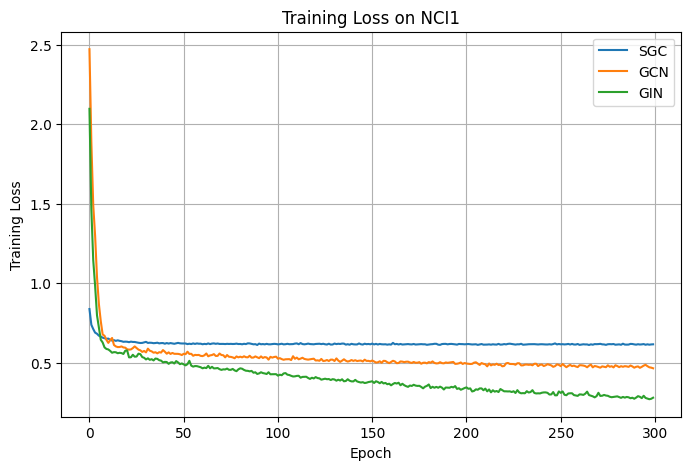

In [28]:
plt.figure(figsize=(8, 5))

for model_name, res in results.items():
    plt.plot(res["train_losses"], label=model_name)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title(f"Training Loss on {DATASET_NAME}")
plt.legend()
plt.grid(True)
plt.show()

12.  Validation accuracy plot

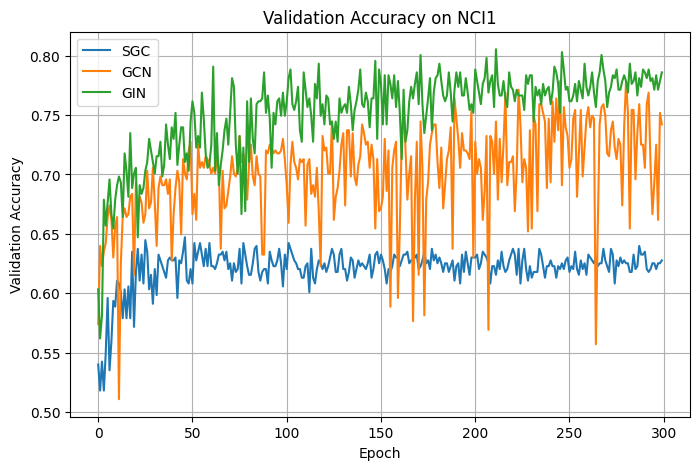

In [29]:
plt.figure(figsize=(8, 5))

for model_name, res in results.items():
    plt.plot(res["val_accs"], label=model_name)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title(f"Validation Accuracy on {DATASET_NAME}")
plt.legend()
plt.grid(True)
plt.show()

13. Test accuracy plot

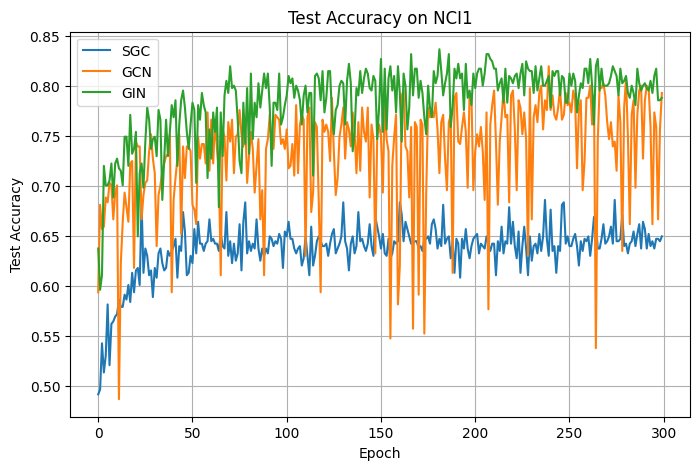

In [30]:
plt.figure(figsize=(8, 5))

for model_name, res in results.items():
    plt.plot(res["test_accs"], label=model_name)

plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title(f"Test Accuracy on {DATASET_NAME}")
plt.legend()
plt.grid(True)
plt.show()

14. Accuracy vs Training Time plot

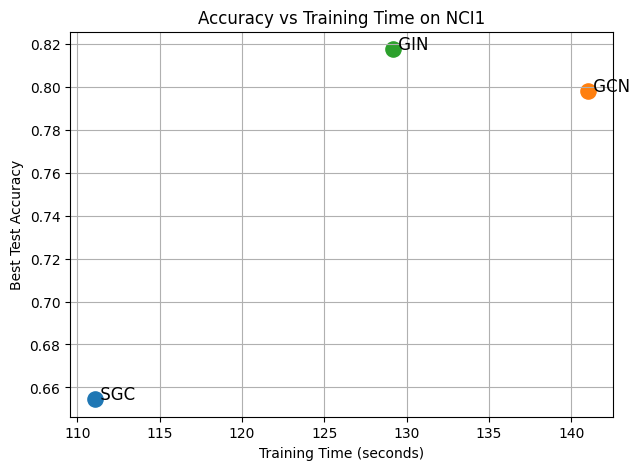

In [ ]:
plt.figure(figsize=(7, 5))

for model_name, res in results.items():
    plt.scatter(
        res["training_time"],
        res["best_test_acc"],
        s=120
    )

    plt.text(
        res["training_time"],
        res["best_test_acc"],
        f" {model_name}",
        fontsize=12
    )

plt.xlabel("Training Time (seconds)")
plt.ylabel("Best Test Accuracy")
plt.title(f"Accuracy vs Training Time on {DATASET_NAME}")
plt.grid(True)
plt.show()